Materials Required
All available in our class github repository:
1. Penguins.csv – Palmer penguins dataset
2. DS6021-Fall26-Anonymized.csv – In class dataset
3. Clinical_trial.csv – New dataset that has been uploaded to our class repository
4. In-class notebooks from 8/31 (comparing_samples.ipynb) and 9/2 (statistical_power.ipynb)

Note: Many of the questions are open ended and allow for multiple perspectives and correct answers.

Activity 1: Comparing two proportions
Using the Palmer penguins dataset, we want to explore comparing two proportions, which we did not get
to in class. We answer the following question: Are penguins that live on Biscoe island larger? We want to
look at the “rate” of large penguins on Biscoe vs the other two islands. Please use the following
definitions and resources:
• What does larger mean? For any penguin, is it larger than median penguin body mass. We can
write this as: peng["is_large"] = peng["body_mass_g"] > peng["body_mass_g"].median()
• You are going to want to look at the fraction of large penguins on Biscoe island vs large penguins
on other islands
• Stats models has a proportions_ztest function that will be useful for this exercise
• The pandas crosstab function might also be useful
Please complete the following:
1. [2pts] Visualize body mass of the penguins across different islands. What does this tell you?
2. [3pts] Using the definitions above, answer the question: Are penguins on Biscoe island larger?
3. [2pts] Now visualize which species of penguins live on each island. How does that change your
answer to the question: Are penguins on Biscoe island larger?
4. [3pts] Repeat the proportion test considering only one species of penguin. Which species did you
choose, and how did that impact your answer?

Activity 2: Digging Further into ANOVA with class data
In class, we looked a little bit at our class data to explore whether and how average number of hours of
sleep per night as a function of years since undergrad.
1. [2 points] Re-bin the data into three groups instead of 5: [<1 year | 1-3 years | 4+ years] and plot
hours of sleep for these three groups.
2. [2 points] Repeat the test for equal variance with these three groups, as well as the ANOVA.
What conclusions can you draw? Are any other assumptions violated?
3. [4 points] Reflection: One thing we have been ignoring in this analysis is the fact that these are
ordered variables: e.g. they aren’t independent buckets like in our penguins dataset where the
different species have no inherent ordering. Here, <1 year means something in relation to 1-3
years and so forth. Please answer the following questions:
a. How are the original buckets reflective of a poor survey design?
b. Does splitting our data into three buckets vs five improve the survey design?
c. If we were redesigning this survey, what would you recommend in order to answer the
question about whether or not students who graduated more recently get more or less
sleep than students who graduated longer ago?
4. [2 points] Reflection: We’ve been using the in-class survey data to help understand concepts
around statistical inference, sample comparisons, and data cleaning. Is this a good dataset to help
understand these concepts? Please explain why or why not, and reflect on what this might tell you
more broadly about data collection, survey design, and drawing conclusions from a particular set
of data.

Activity 3: Migraine Drug Formulations
A pharmaceutical company tested three formulations of a pain relief medicine for migraine headache
sufferers. 27 volunteers were selected and 9 were randomly assigned to one of the three drug
formulations. Subjects took the drug during their next migraine episode and reported pain on a 1–10 scale
(1 = no pain, 10 = extreme pain) 30 minutes after taking the drug. The dataset, Clinical_trial, contains
the results of this experiment.
Note: Some of the questions are purposefully left open-ended as there are multiple approaches to solve
these problems.
1. [2pts] Visualize the pain ratings across the three drug formulations. Provide a brief interpretation
of what the graph reveals.
2. [5pts] As the Data Scientist on a team of researchers at the pharmaceutical company, your main
task is to evaluate which drug formulation most effectively reduces migraine pain. Formulate the
appropriate hypotheses, perform the relevant statistical test(s), and communicate each step of
your analysis and results in clear, accessible written language for non-technical team members.
3. [3pts] Suppose we wanted to build a supervised learning model using this dataset. What would be
the prediction goal? Note that you do not have to build a predictive model to answer this question.
Discuss in what situations a pharmaceutical company might use statistical inference vs prediction.

Activity 4: Statistical Power
In class, we did some simulations to explore concepts around statistical power. We specifically looked at
an example of an A/B test to understand how long it would take us to detect a 5% difference in average
sales when comparing two websites. Now let’s assume you are presented with the following scenario:
A business analyst (BA) comes to you needing help making a decision. So far, they have been running an
A/B test for 4 days between two versions of an app, and they want to look at the mean length of time
spent on the app, with more time being better. They have presented you with the following information:
• Each day, 300 users are in the control (A) and treatment (B) groups.
• A is the version of the app currently in production, and users typically spend an average of 12
minutes on the App with a standard deviation of +/- 4 minutes.
• After running this A/B test for 4 days, they have observed that users who receive version B of the
app spend an average of 12.5 minutes on the App vs 12 for version A.
This BA is getting some pressure from their leadership to move everyone to version B of the app, but they
want you to tell them whether or not they can trust the results they have so far.
1. [3pts] Assuming an alpha of 0.05 and a power of 0.8, what is the minimum effect size we could
measure after 4 days?
2. [3pts] Based on your answer to the first question, would you recommend discontinuing the A/B
test and moving everyone to the B version of the app? If yes, why? If not, why not?
3. [5pts] Create a visualization and three bullet points that you could present to leadership about
your analysis to help them make a decision.
4. [4pts] What if your BA collaborator came back to you and said the test was being discontinued
(regardless of your analysis)—how would that change how you frame the results to leadership?
Deliverables
For each activity, please include the following:
• All code used to complete each of the activities. This can be turned in as a single Jupyter
notebook, multiple Jupyter notebooks, or one or more .py files. Up to you!
• For open ended questions, please include a few sentences or a paragraph answering the question.
This text can be included in your Jupyter notebook as a markdown cell or a separate document.
• Per our policy on Generative AI detailed in the syllabus, if you use it to generate code, you need
to flag how and where you used it, and how you ascertained the correctness of what you did.
Note: You are not allowed to use Generative AI for any of the reflection questions.

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.formula.api import ols
from statsmodels.stats.power import TTestIndPower
from scipy import stats

In [2]:
peng = pd.read_csv("C:\\Users\\witze\\Downloads\\DS6021_F26\\data\\penguins.csv")
peng.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


<function matplotlib.pyplot.show(close=None, block=None)>

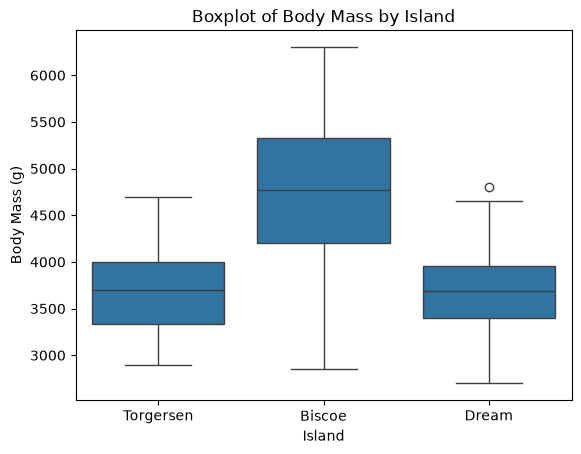

In [3]:
sns.boxplot(x='island', y='body_mass_g', data=peng)
plt.title('Boxplot of Body Mass by Island')
plt.xlabel('Island')
plt.ylabel('Body Mass (g)')
plt.show

This visualization tells me that the average penguin body mass at Biscoe Island is significantly larger than the penguins at Torgersen and Dream Islands.

In [4]:
peng["is_large"] = peng["body_mass_g"] > peng["body_mass_g"].median()
peng.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,is_large
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,False
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,False
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,False
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007,False
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,False


In [10]:
peng["is_large"] = peng["body_mass_g"] > peng["body_mass_g"].median()

Biscoe = peng[peng['island'] == 'Biscoe']
NotBiscoe = peng[peng['island'] != 'Biscoe']

count = np.array([Biscoe['is_large'].sum(), NotBiscoe['is_large'].sum()])
nobs = np.array([len(Biscoe), len(NotBiscoe)])

stat, p_val = proportions_ztest(count=count, nobs=nobs)

print("Biscoe prop large: ", round(Biscoe["is_large"].mean(), 3), " n =", len(Biscoe))
print("Other prop large:  ", round(NotBiscoe["is_large"].mean(), 3), " n =", len(NotBiscoe))
print("z-statistic:", round(stat, 3))
print("p-value:", p_val)

Biscoe prop large:  0.78  n = 168
Other prop large:   0.199  n = 176
z-statistic: 10.778
p-value: 4.387014717847392e-27


Ho: Biscoe Penguins are the same size as the penguins on the other two islands.
Ha: Biscoe Penguins are larger than the penguins on the other two islands.
With such a low p-value, we reject the null hypothesis that the penguins on Bisoe island are the same size as the other islands.

<Axes: xlabel='island'>

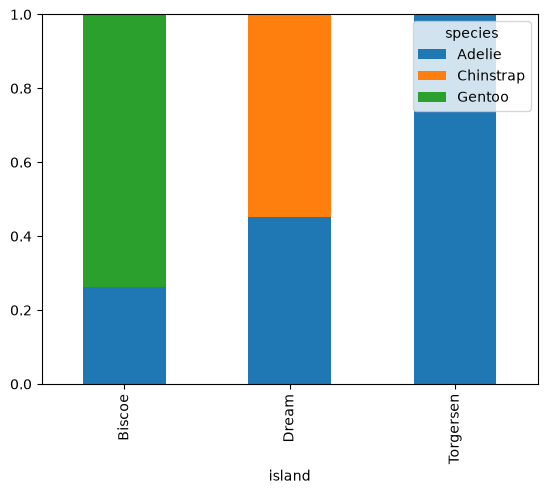

In [ ]:
peng.groupby('island')['species'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)
#VScode helped me by autofilling some of the plot code.

Seeing how similarily sized the penguins are on the Dream and Torgersen islands, I'm saying that Biscoe penguins are bigger. This visualization shows us that there's a significant difference in the species of penguin per island.

In [ ]:
Adelie = peng[peng['species'] == 'Adelie']

biscoe = Adelie[Adelie['island'] == 'Biscoe']
NayBiscoe = Adelie[Adelie['island'] != 'Biscoe']

count = np.array([biscoe['is_large'].sum(), NayBiscoe['is_large'].sum()])
nobs = np.array([len(biscoe), len(NayBiscoe)])

stat, p_val = proportions_ztest(count=count, nobs=nobs)

print("Biscoe prop large: ", round(biscoe["is_large"].mean(), 3), " n =", len(biscoe))
print("Other prop large:  ", round(NayBiscoe["is_large"].mean(), 3), " n =", len(NayBiscoe))
print("z-statistic:", round(stat, 3))
print("p-value:", p_val)

Biscoe prop large:  0.205  n = 44
Other prop large:   0.222  n = 108
z-statistic: -0.24
p-value: 0.8105352847605213


Ho: The Biscoe Penguin size is affected by species.
Ha: The Biscoe Penguin size is not affected by species.
With this high p-value, we fail to reject the null hypothesis. I believe the Gentoo population makes up the large mass of the Biscoe penguins.

In [ ]:
#AI: I use gen AI to help me with the dict for this box. 

df = pd.read_csv("C:\\Users\\witze\\Downloads\\DS6021_F26\\data\\DS6021-Fall26-Anonymized.csv")

df_sleep = df[[
    "How many years ago did you receive your undergraduate degree?",
    "How many hours do you sleep in a typical night?"
]].rename(columns={
    "How many years ago did you receive your undergraduate degree?": "years_since_undergrad",
    "How many hours do you sleep in a typical night?": "sleep_hrs"
})

bin_mapping = {
    "< 1 year": "< 1 year",
    "1-3 years": "1-3 years",
    "4-6 years": "4+ years",
    "7-10 years": "4+ years",
    "10+ years": "4+ years"
}
df_sleep["years_since_undergrad"] = df_sleep["years_since_undergrad"].map(bin_mapping)

year_order = ["< 1 year", "1-3 years", "4+ years"]
df_sleep["years_since_undergrad"] = pd.Categorical(
    df_sleep["years_since_undergrad"], categories=year_order, ordered=True
)

bounds = df_sleep["sleep_hrs"].str.extractall(r"(\d+\.?\d*)")[0].astype(float)
df_sleep["sleep_hrs"] = bounds.groupby(level=0).agg(lambda x: x.head(2).mean())
df_sleep.head()

,years_since_undergrad,sleep_hrs
0,4+ years,8.0
1,1-3 years,8.0
2,< 1 year,8.0
3,< 1 year,8.0
4,1-3 years,8.0


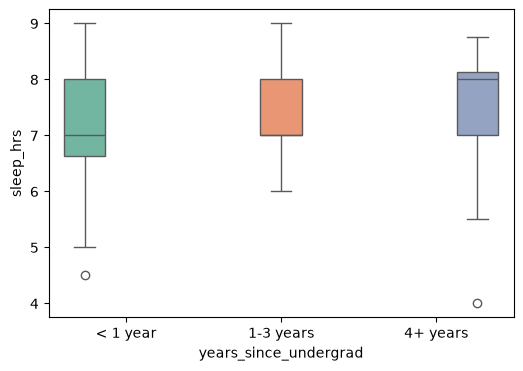

In [18]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df_sleep,
    x="years_since_undergrad",
    y="sleep_hrs",
    hue="years_since_undergrad",
    palette="Set2"
)

plt.xlabel("years_since_undergrad")
plt.ylabel("sleep_hrs")
plt.show()

In [19]:
yrs = ['< 1 year', '1-3 years', '4+ years']
print(df_sleep.groupby("years_since_undergrad")["sleep_hrs"].agg(["count", "mean", "std"]).round(2))

groups = [df_sleep.loc[df_sleep["years_since_undergrad"] == s, "sleep_hrs"]
          for s in yrs]

print("Levene's test p-value:", round(stats.levene(*groups).pvalue, 4))

                       count  mean   std
years_since_undergrad                   
< 1 year                  50  7.07  0.98
1-3 years                 17  7.41  0.85
4+ years                  19  7.42  1.17
Levene's test p-value: 0.75


In [22]:
model = ols("sleep_hrs ~ C(years_since_undergrad)", data=df_sleep).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                             sum_sq    df         F    PR(>F)
C(years_since_undergrad)   2.516123   2.0  1.252339  0.291179
Residual                  83.379226  83.0       NaN       NaN


From the anova table, we can conclude a lack of evidence to prove one's years since undergrad has an effect on their sleep. As for assumptions violated, I'm not seeing any violated assumptions based Levene's test.

3a - The survey design forces a numerical variable to be a categorical one. Somebody who took one gap year is mashed into the same group as somebody who worked a job for 3 years. 

3b - I don't think it helps the survey design. Having even less categories allows for less variety making the data even more coarse. 

3c - I'd recommend surveying students for numerical answers on the amount of time between now and their undergrad graduation. 

4 - I believe this is a good dataset for understanding the importance of data collection methods and hands-on experience for data cleaning. I've been given time to reflect on how this data was collected and how there are better ways to sample data. As for data cleaning, the dataset was clearly messy and gave us great experience for cleaning the dataset. I will admit, however, I think this dataset wasn't great for drawing conclusions from data. We completed our anova analysis and got experience in running anova through python code, but we didn't get to make any serious conclusions from this data. 

In [24]:
Trial = pd.read_csv("C:\\Users\\witze\\Downloads\\DS6021_F26\\data\\Clinical_trial.csv")
Trial.head()

,Drug,Pain_Rating
0,A,4
1,A,5
2,A,4
3,A,3
4,A,2


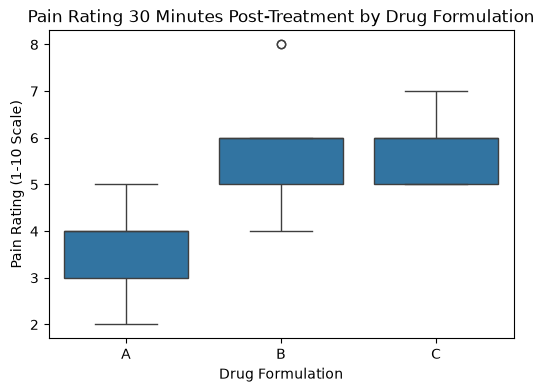

In [27]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='Drug', y='Pain_Rating', data=Trial)
plt.title('Pain Rating 30 Minutes Post-Treatment by Drug Formulation')
plt.xlabel('Drug Formulation')
plt.ylabel('Pain Rating (1-10 Scale)')
plt.show()

The graph reveals that patients who took drug a reported less pain than patients who took drugs b and c. Patients who took drug b and c were very similar, but with drug c having less success.

In [ ]:
#Ho: The mean pain rating is the same for all drug formulations.
#Ha: At least one drug formulation has a different mean pain rating.

#I'm choosing to use ANOVA for this analysis at a significance level of 0.05.
Model = ols("Pain_Rating ~ C(Drug)", data=Trial).fit()
anova = sm.stats.anova_lm(Model, typ=2)
print(anova)
#In the future, I'd try to prove drug A specifically is different, but I'm running on time.

             sum_sq    df         F    PR(>F)
C(Drug)   28.222222   2.0  11.90625  0.000256
Residual  28.444444  24.0       NaN       NaN


At our significance level of 0.05, we reject the null hypothesis with the p-value of 0.000256. At least one of the drug forms reports significantly different results from the other two drug forms. 

In non-technical terms, this table reveals that one of the drug forms is proven to produce different results from the other two. Looking at the above boxplots, one can assume it's drug A. 

3.3 - The prediction goal would be to predict a patient's pain score based on the drug form they were given and other possible medical characteristics. A pharmaceutical company would use statistical inference to prove whether or not their observations are significant or not. They would then use prediction to make their recommendations on which drug form is the best for pain suppression with possible variation based on other medical variables by patient.

In [ ]:
#AI: I used the notebooks and some help with AI to get all of this typed out. 
#I input the notebook code and asked for an output with relevant values. 

SD = 4.0                  
N_PER_DAY = 300           
DAYS = 4
N_FOUR_DAYS = N_PER_DAY * DAYS 
ALPHA = 0.05
TARGET_POWER = 0.80

analysis = TTestIndPower()

min_cohens_d = analysis.solve_power(
    nobs1=N_FOUR_DAYS, 
    alpha=ALPHA, 
    power=TARGET_POWER, 
    ratio=1.0, 
    alternative="two-sided"
)

min_effect_minutes = min_cohens_d * SD

print(f"Sample size per group (4 days) = {N_FOUR_DAYS}")
print(f"Minimum detectable Cohen's d   = {min_cohens_d:.4f}")
print(f"Minimum detectable effect      = {min_effect_minutes:.4f} minutes")

Sample size per group (4 days) = 1200
Minimum detectable Cohen's d   = 0.1144
Minimum detectable effect      = 0.4577 minutes


After 4 days, the minimum effect size is 0.457 minutes.
4.2 - The observed effect(0.5 minutes) is larger than the the minimum effect size, so I would not recommend discontinuing the A/B test and moving everyone to the B version of the app. 

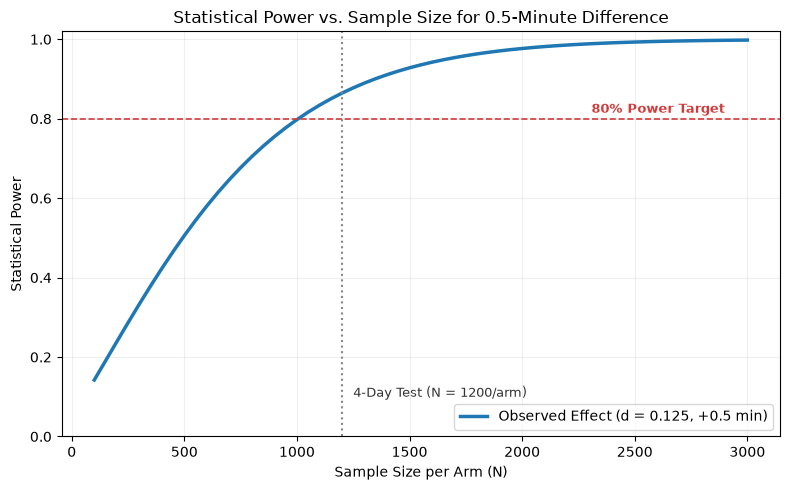

In [ ]:
#AI: Similarily to the last box of code, I used AI to help me speed the coding process.
#I input the power level plot code from the notebook and asked for a relevant output.

SD = 4.0
MEAN_CONTROL = 12.0
OBSERVED_DIFF = 0.5  
ALPHA = 0.05
N_FOUR_DAYS = 300 * 4  

cohens_d = OBSERVED_DIFF / SD  # d = 0.125

analysis = TTestIndPower()
n_grid = np.arange(100, 3001, 50)
powers = analysis.power(effect_size=cohens_d, nobs1=n_grid, alpha=ALPHA, ratio=1.0)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(n_grid, powers, color="#1f77b4", linewidth=2.5, label=f"Observed Effect (d = {cohens_d:.3f}, +0.5 min)")

ax.axhline(0.80, color="#d03b3b", linestyle="--", linewidth=1.2)
ax.text(2900, 0.815, "80% Power Target", ha="right", color="#d03b3b", fontsize=9, fontweight="bold")

ax.axvline(N_FOUR_DAYS, color="#898781", linestyle=":", linewidth=1.5)
ax.text(N_FOUR_DAYS + 50, 0.10, f"4-Day Test (N = {N_FOUR_DAYS}/arm)", color="#333333", fontsize=9)

ax.set_xlabel("Sample Size per Arm (N)")
ax.set_ylabel("Statistical Power")
ax.set_ylim(0, 1.02)
ax.set_title("Statistical Power vs. Sample Size for 0.5-Minute Difference")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

4.3 For Leadership:
1 - In 4 days, our experiment is meant to find a significant increase in time longer than 0.457 minutes
2 - Version B of the app does have an increase in time larger than the minimum 0.457 minutes. 
3 - With the move already in place and the experiment proving the move isn't wasting time, discontinuing wouldn't be the right move.

4.4 - If the BA collaborator came back with the news that he discontinued the test, I would frame the results in a way that the difference in time wasn't enough despite it surpassing the minimum. I'd then present my alternative suggestion to retest after using a larger sample and waiting for longer in order to improve the power of the test. 